# CNN Explainers: Integrated Gradients + Grad-CAM

## Install packages

In [1]:
# captum has both explainer methods built in, don't need to write these from scratch
!pip install captum datasets --quiet


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Imports and config

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import transforms
from datasets import load_dataset
from captum.attr import IntegratedGradients, LayerGradCam
from captum.attr import visualization as viz

IMG_SIZE = 150   # gotta match what the model was trained on or everything breaks
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

/workspaces/eng-ai-agents/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## Load the trained model

In [3]:
# copy-pasted this straight from the training notebook, needs to be identical
# or load_state_dict throws a fit about mismatched shapes
class SmallConvNet(nn.Module):
    def __init__(self, dropout: bool = False):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,   32,  3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,  64,  3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,  128, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5) if dropout else nn.Identity(),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = x.view(x.size(0), -1)   # flatten before feeding into the linear layers
        return self.classifier(x).squeeze(1)

# no training happening here, just loading up weights that already exist
model = SmallConvNet(dropout=True)
model.load_state_dict(torch.load("cats_and_dogs_small.pth", map_location=DEVICE))
model.to(DEVICE)
model.eval()   # don't forget this, otherwise dropout stays on and predictions get flaky
print("Model loaded, set to eval mode")

Model loaded, set to eval mode


## Grab some test images (3 correct, 1 wrong)

In [4]:
label_names = ["cat", "dog"]

# same transform as validation/test during training, no augmentation here,
# we want to see how the model behaves on normal, unmodified images
basic_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

# pulling from the same test split we already got the 71.8% accuracy from
ds_dict = load_dataset("pantelism/cats-vs-dogs")
test_split = ds_dict["test"]

correct_examples, wrong_examples = [], []

# just looping through images, running each one through the model, and
# sorting into two piles: got it right / got it wrong. bail out early
# once we've got enough of both, no need to churn through all 1000
with torch.no_grad():
    for i in range(len(test_split)):
        sample = test_split[i]
        img_pil = sample["image"].convert("RGB")
        label = int(sample["label"])

        img_tensor = basic_tf(img_pil).unsqueeze(0).to(DEVICE)   # unsqueeze adds the batch dim
        prob = torch.sigmoid(model(img_tensor)).item()   # raw output is a logit, sigmoid squashes it to 0-1
        pred = int(prob > 0.5)   # 0 = cat, 1 = dog

        entry = {"img_tensor": img_tensor.squeeze(0).cpu(),
                  "label": label, "pred": pred, "prob": prob}

        if pred == label and len(correct_examples) < 3:
            correct_examples.append(entry)
        elif pred != label and len(wrong_examples) < 1:
            wrong_examples.append(entry)

        if len(correct_examples) >= 3 and len(wrong_examples) >= 1:
            break   # got what we need, stop early

examples = correct_examples + wrong_examples
print(f"Got {len(correct_examples)} correct examples and {len(wrong_examples)} wrong example(s)")

Got 3 correct examples and 1 wrong example(s)


In [5]:
# images got normalized to roughly [-1, 1] earlier, undo that here so
# matplotlib shows them as normal-looking photos instead of weird colors
def denormalize(img_tensor):
    img = img_tensor.permute(1, 2, 0).numpy()   # torch is CHW, matplotlib wants HWC
    return np.clip(img * 0.5 + 0.5, 0, 1)

## Method 1: Integrated Gradients explanation

The main idea behind this method is that, as you transition from an all-black (blank) image into the final image, you're able to determine at each step which pixels are affecting the prediction towards "cat" versus "dog." The sum total of these effects will provide a number for each pixel, showing how much each one affected the overall output.

You use the all-black background as a reference point. Without some basis of comparison there would be no way to know whether the small amount that a particular pixel affects the models decision about whether the object in the picture is a cat or a dog means anything or if the model simply doesn't care.

However, using this method produces a high level of noise, which can make it difficult to distinguish between unimportant pixels and important ones -- the result often appears similar to static on an older television. Also, since this method needs to run the machine learning algorithm multiple times per image, it takes longer than methods such as Grad-CAM which only requires running the algorithm once.

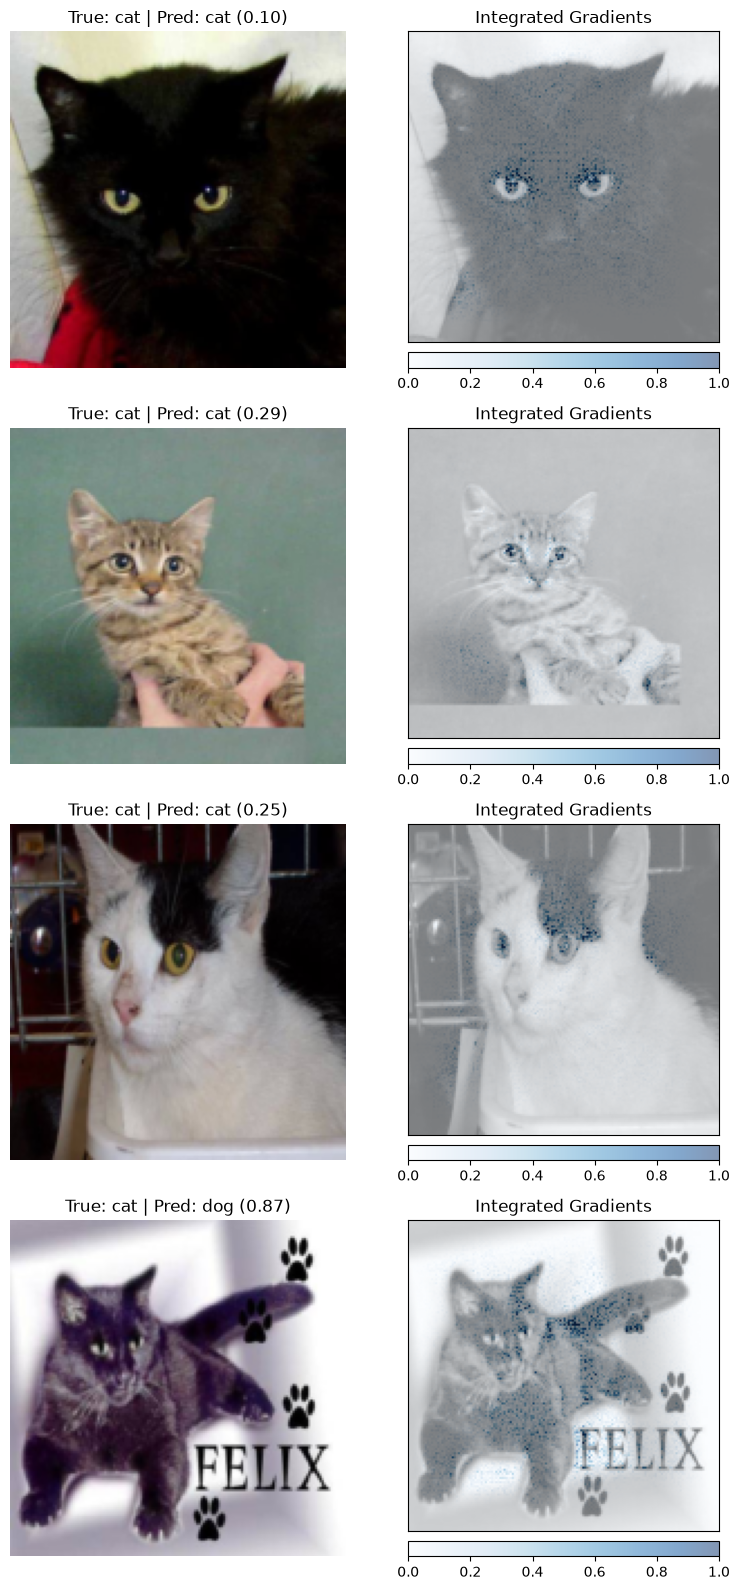

In [6]:
ig = IntegratedGradients(model)

fig, axes = plt.subplots(len(examples), 2, figsize=(8, 4 * len(examples)))

for row, ex in enumerate(examples):
    input_tensor = ex["img_tensor"].unsqueeze(0).to(DEVICE)

    # all-black image = the "blank slate" reference point. IG basically checks
    # how much each pixel matters as we go from nothing to the real photo
    baseline = torch.zeros_like(input_tensor)

    # target=None means explain whatever the model actually predicted, not
    # the true label -- important since we want to explain its decision, right or wrong
    # n_steps=50 is how many steps we sample between the baseline and the real image
    attributions = ig.attribute(input_tensor, baseline, target=None, n_steps=50)
    attr_np = attributions.squeeze(0).cpu().permute(1, 2, 0).numpy()

    orig_np = denormalize(ex["img_tensor"])

    # left side: just the plain photo with true/predicted label on top
    axes[row, 0].imshow(orig_np)
    axes[row, 0].axis("off")
    axes[row, 0].set_title(f"True: {label_names[ex['label']]} | Pred: {label_names[ex['pred']]} ({ex['prob']:.2f})")

    # right side: the IG heatmap laid over the photo
    viz.visualize_image_attr(
        attr_np, orig_np, method="blended_heat_map", sign="absolute_value",
        show_colorbar=True, plt_fig_axis=(fig, axes[row, 1]), use_pyplot=False,
    )
    axes[row, 1].set_title("Integrated Gradients")

plt.tight_layout()
plt.savefig("integrated_gradients.png", dpi=120, bbox_inches="tight")
plt.show()

For all three cats, the black cat, the tabby kitten, and the black & white cat, the dots stay centered on the eyes with very little spreading past the face. For the misclassified cat, the dots land on the paw prints and the "FELIX" text at the bottom of the image, not just on the cat.

## Method 2: Grad-CAM explanation

Grad CAM works different from IG, rather than looking at every pixel individually, Grad CAM looks inside the network at a very small grid where each node is effectively saying "yes, i see a feature from something i was trained on in that area". The weight of each node is then used to generate a single heatmap. That heatmap is then stretched back to the original image size, so it can be directly overlaid.

I chose the final convolutional layer as my test case. At this stage the model has evolved beyond identifying simple edges or color, to identify larger features which are indicative of specific parts (ie "an ear").

That said; since the final layer is a 7x7 grid, regardless of how far I blow it up, the output will always be coarser grained, and won't pinpoint individual detail.

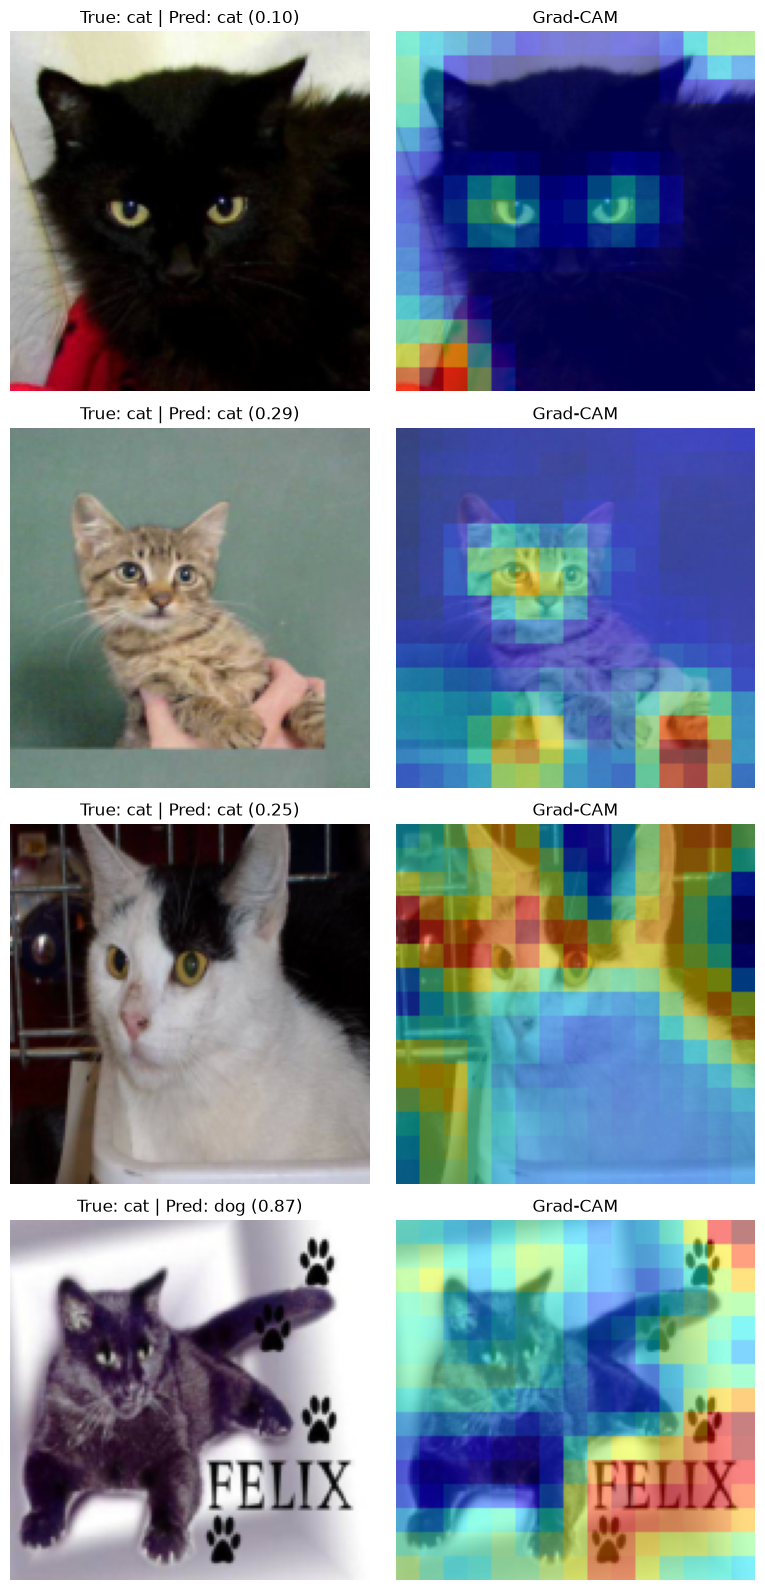

In [7]:
# features[9] is the last conv layer, right before the final relu + maxpool.
# grad-cam needs to hook into a conv layer somewhere, using the last one
# gives the most "this is a meaningful shape" info, just at low resolution
last_conv_layer = model.features[9]
grad_cam = LayerGradCam(model, last_conv_layer)

fig, axes = plt.subplots(len(examples), 2, figsize=(8, 4 * len(examples)))

for row, ex in enumerate(examples):
    input_tensor = ex["img_tensor"].unsqueeze(0).to(DEVICE)
    orig_np = denormalize(ex["img_tensor"])

    # same target=None reasoning as before -- explain the predicted class
    # this spits out a tiny 7x7 map since that's the resolution of the last conv layer
    cam_attr = grad_cam.attribute(input_tensor, target=None)

    # blow that tiny map back up to full image size so we can lay it on top
    cam_upsampled = LayerGradCam.interpolate(cam_attr, (IMG_SIZE, IMG_SIZE))
    cam_np = cam_upsampled.squeeze().cpu().detach().numpy()

    # left side: plain photo again
    axes[row, 0].imshow(orig_np)
    axes[row, 0].axis("off")
    axes[row, 0].set_title(f"True: {label_names[ex['label']]} | Pred: {label_names[ex['pred']]} ({ex['prob']:.2f})")

    # right side: photo + grad-cam heatmap on top, half transparent so we can still see the photo
    axes[row, 1].imshow(orig_np)
    axes[row, 1].imshow(cam_np, cmap="jet", alpha=0.5)
    axes[row, 1].axis("off")
    axes[row, 1].set_title("Grad-CAM")

plt.tight_layout()
plt.savefig("grad_cam.png", dpi=120, bbox_inches="tight")
plt.show()

For the black cat, the tabby cat, and the black & white cat, the warm yellow-red colors sit on the face and eyes, but also spread onto other things in the picture, not just the animal. Everywhere else stays blue. For the misclassified cat, the bright yellow-red color lands right on the paw prints and the "FELIX" text, not just the cat's body.

## Comparing the two, and what the mistake tells me

There were similarities between where the two methods focused (same general area around the face/eye), for all three good examples. IG was much more specific about the eyes, while Grad-CAM had a larger focus point that included some of the area surrounding the face/animal. While the two methods produced slightly different results, they tended to point at roughly the same general location. It would seem that when you have agreement between multiple methods (IG and Grad-CAM), it likely indicates that the model is producing responses based upon actual properties of objects, instead of simply producing random responses.

It would also make sense that Grad-CAM has a tendency to pick-up on other things in the environment surrounding the cat, because of the nature of Grad-CAM being somewhat fuzzy and unable to produce a clear separation between 'the cat' and 'stuff near the cat.' However, it does provide information on how vague the model is when trying to determine what exactly defines 'the cat.'

The mislabeled image provided perhaps the most interesting results. IG and Grad-CAM both placed a large amount of emphasis on the paw-prints and the "FELIX" wording within the mislabeled image. Since both methods independently identified those non-cat items, it could suggest that there is a correlation made by the model between graphical or watermark elements and classification to a particular category, and not necessarily based upon real-world dog/cat characteristics. It is only one example; however, I believe it should be flagged as something that might represent a potential shortcut.